# Preprocessing of EMG data in MUniverse

This notebook demonstrates how EMG data is preprocessed in **``MUniverse``** to make EMG recordings decomposition-ready.

Users can thereby select among the different filter types showcased below.

This includes different types of bandpass and notch (i.e., stopband) filters.   

All these options can be used within ``MUniverse's`` decomposition pipelines. However, you can also preprocess your data using your own scripts and disable the built-in preprocessing steps. 

## Tutorial example 

We will first motivate the use of digital filters for pre-processing by inspecting and processing a single recording.

Before starting the actual investigation, we will import some essential dependencies and define some helper functions to help us analyze the data. In particular, we will use Welch's method to estimate the power spectral density (PSD) for each channel [1]. 



In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from muniverse.algorithms.core import bandpass_signals, notch_signals
from muniverse.utils.bids_routines import EMGBIDSRecording, run_bids_validator

from pathlib import Path

In [40]:
from scipy.signal import welch

def calc_PSD(sig, fsamp=2048, nperseg=2048, noverlap=2048/2):
    """
    Compute the power spectral density for each channel using Welch's method.

    Parameters
    ----------
    sig : np.ndarray
        Multi-channel signal with shape ``(n_channels, n_samples)``
    fsamp : float 
        Sampling rate in Hz
    nperseg :int 
        Number of data points per segment
    overlap : int
        Number of overlapping samples

    Returns
    -------
    P : np.ndarray
        Estimated power spectral density with shape ``(n_channels, n_perseg // 2 + 1)``   
    f: np.ndarray
        Array of sample frequencies ``(n_perseg // 2 + 1)``        
    """

    f, _ = welch(sig[0,:], fs=fsamp, nperseg=nperseg, noverlap=noverlap)

    P = np.zeros((sig.shape[0], f.shape[0]))

    for i in range(sig.shape[0]):
        _ , P[i,:] = welch(sig[i,:], fs=fsamp, nperseg=nperseg, noverlap=noverlap)

    return P, f

def get_events_indices(events):
    """
    Helper function to extract the indices 
    corresponding to the start and end of a task
    """    

    start_idx = events[events["event_type"] == "muscle_on"]["sample"].tolist()[0]
    end_idx = events[events["event_type"] == "muscle_off"]["sample"].tolist()[0]

    return start_idx, end_idx


def analyse_signal(sig, noise, fsamp=2048, plfreq=50, verbose=True):
    """
    Helper function to analyse the quality of multi-channel
    high density surface EMG data

    Parameters
    ----------
    sig : np.ndarray
        Array of EMG data ``(n_channels, n_samples)``
    noise : np.ndarray
        Array of a noise data ``(n_channels, n_samples)``
    fsamp : float , default 2048
        Sampling rate in Hz
    plfreq : float , default 50
        Powerline frequency in Hz     
    verbose : bool , default True
        If True, print performance metrics

    Returns
    -------
    results : dict
        Dictonary of signal quality markers

    """

    # Calculate the SNR
    p_sig = np.mean(sig**2)
    p_noise = np.mean(noise**2)
    snr = 10 * np.log10(p_sig / p_noise) 

    # Calculate the RMS of the noise
    rms_noise = p_noise**0.5

    # Calculate the power spectral density (PSD)
    PSD_noise, fn = calc_PSD(noise, fsamp=fsamp, nperseg=fsamp, noverlap=fsamp//2)
    PSD_sig, fs = calc_PSD(sig, fsamp=fsamp, nperseg=fsamp, noverlap=fsamp//2)

    # Calculate the median PSD (across channels)
    medPSD_noise = np.median(PSD_noise, axis=0)
    medPSD_sig = np.median(PSD_sig, axis=0)

    # Get the median noise floor
    idx = np.where((fn > 20) & (fn < 500))[0]
    med_noise_pow = np.median(medPSD_noise[med_idx])

    # Get the power line interference
    idx = np.where((fn > plfreq - 10) & (fn < plfreq + 10))[0]
    pli_db = 10 * np.log10(np.max(medPSD_noise[idx]) / np.median(medPSD_noise[idx]))

    if verbose:
        print(f"SNR: {snr:.2f} dB.")
        print(f"RMS-Noise: {rms_noise:.5f} mV")
        print(f"Median Noise Floor: {med_noise_pow:.3e} mV^2/Hz")
        print(f"Power Line Interference: {pli_db:.2f} dB")

    return {
        "freqs": fn,
        "PSD_noise": PSD_noise,
        "PSD_sig": PSD_sig,
        "SNR": snr,
        "RMS_noise": rms_noise,
        "Noise_floor": med_noise_pow,
        "Power_line_interferenece": pli_db
    }    

def plot_data(emg_data, path, target, results, dtype="Raw", fsamp=2048):
    """
    Helper function to plot a few channels from the 
    recording together with the power spectrum
    """

    # Get the number of samples in the recording
    n_samples = data.shape[1]

    # Extract the data from results dictonary
    f = results["freqs"]
    Pn = results["PSD_noise"]
    Ps = results["PSD_sig"]

    # Select some channels
    channels = np.arange(13,25)
    t = np.linspace(0, (nsamples-1)/fsamp, nsamples)

    # Set up a Figure
    fig, ax = plt.subplots(1,3, figsize=(18,6))

    # First plot the Full signal
    for i, ch_idx in enumerate(channels):
        trace = emg_data[ch_idx, :]
        ax[0].plot(t,trace + 1 * i, lw=0.5)
    ax[0].plot(t, target/3, lw=2, color="gray")
    ax[0].plot(t, path/3, lw=1, color="black")    
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Amplitude + offset (mV)")
    ax[0].set_ylim(-1.5, len(channels) + 1)
    ax[0].set_title(f"{dtype} EMG signals")
    # Now plot 200 ms of the signal
    for i, ch_idx in enumerate(channels):
        trace = emg_data[ch_idx, :]
        ax[1].plot(t,trace + 1 * i, lw=0.5)  
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Amplitude + offset (mV)")
    ax[1].set_ylim(-1.5, len(channels) + 1)
    ax[1].set_xlim(24.9,25.1)
    ax[1].set_xticks([24.9, 25, 25.1])
    ax[1].set_title(f"{dtype} EMG signals (zoom)")
    # Plot the PSD
    ax[2].semilogy(f, np.ones(len(f)) * 5.21e-8, color = "darkgreen", linestyle="dashed", lw=1)
    ax[2].semilogy(f, np.ones(len(f)) * 20.83e-8, color = "green", linestyle="dashed", lw=1)
    ax[2].semilogy(f, np.ones(len(f)) * 46.87e-8, color = "orange", linestyle="dashed", lw=1)
    ax[2].semilogy(f, np.ones(len(f)) * 83.33e-8, color = "red", linestyle="dashed", lw=1)
    ax[2].semilogy(f,Pn.T, lw=0.1, color=[0.7, 0.7, 1])
    ax[2].semilogy(f,Ps.T, lw=0.1, color=[1, 0.7, 0.7])
    ax[2].semilogy(f,np.percentile(Pn, 50, axis=0), lw=1, color="blue", label="noise")
    ax[2].semilogy(f,np.percentile(Ps, 50, axis=0), lw=1, color="red", label="signal")
    ax[2].set_xlabel("Frequency (Hz)")
    ax[2].set_ylabel("PSD (mV$^2$/Hz)")
    ax[2].set_ylim(1e-9, 1e-2)
    ax[2].legend()
    ax[2].set_title(f"Power spectral density ({dtype} data)")
    plt.show()



#### Loading some test data

We will select one of the experimental recordings (Avrillon et al 2024) from the MUniverse dataset collection.

You can download it from Dataverse: https://doi.org/10.7910/DVN/L9OQY7

Having this BIDS-EMG dataset on the harddrive we can import it into this workspace. This will not only allow us to load the data, but also all relevant recording metadata that is needed to process the data:

- Here, the most important recoring metadata is the sampling rate, the local power line frequency and the number of EMG channels.
- To get a better idea on the recording we will also quickly inspect the channel specific metadata, e.g., showing which channels contain non EMG data such as the requested and perfomed torque in the given isometric task. 
- Latsly, we convert the EDF data into numpy arrays for further processing. 

In [41]:
# Load a BIDS recording stored on your hard drive.
emg_recording = EMGBIDSRecording(
    root=str(Path.home()) + "/Downloads/Avrillon_et_al_2024",
    subject_label="13",
    task_label="isometric20percentmvc",
    inherited_metadata=["electrodes.tsv", "coordsystem.json", "events.json"],
    inherited_level=["subject", "subject", "dataset"],
)
emg_recording.read()

# Extract some recording metadata
nchan = emg_recording.emg_sidecar["EMGChannelCount"]    # Number of EMG channels
fsamp = emg_recording.emg_sidecar["SamplingFrequency"]  # Sampling rate in Hz    
pfreq = emg_recording.emg_sidecar["PowerLineFrequency"] # Power line frequency in Hz

# Show the channel the channel sidecar
cols = ["name", "type", "units", "description", "group", "target_muscle", "group"]
print(emg_recording.channels.loc[:, cols].head().to_string())
print("...")
print(emg_recording.channels.loc[:, cols].tail().to_string())

# Now we can extract the emg data and misc channels
data = emg_recording.data

emg_data = data[1:nchan,:]
requested_path = data[256,:]
performed_path = data[257,:]

nsamples = emg_data.shape[1]



   name type units    description  group           target_muscle  group
0  Ch01  EMG    mV  monopolar EMG  Grid1  right vastus lateralis  Grid1
1  Ch02  EMG    mV  monopolar EMG  Grid1  right vastus lateralis  Grid1
2  Ch03  EMG    mV  monopolar EMG  Grid1  right vastus lateralis  Grid1
3  Ch04  EMG    mV  monopolar EMG  Grid1  right vastus lateralis  Grid1
4  Ch05  EMG    mV  monopolar EMG  Grid1  right vastus lateralis  Grid1
...
      name  type        units     description  group           target_muscle  group
253  Ch254   EMG           mV   monopolar EMG  Grid4  right vastus lateralis  Grid4
254  Ch255   EMG           mV   monopolar EMG  Grid4  right vastus lateralis  Grid4
255  Ch256   EMG           mV   monopolar EMG  Grid4  right vastus lateralis  Grid4
256  Ch257  MISC  percent MVC  Requested Path    NaN                     NaN    NaN
257  Ch258  MISC  percent MVC  Performed Path    NaN                     NaN    NaN


#### Background on quantification of signal quality

EMG recordings are affected by multiple sources of noise [2], including
- instrumentation noise --> contamination due to the data aquistition system (AD conversion, thermal/Johnson noise, ...)
- interference --> unwanted signals that are picked up together with EMG (e.g., power-line noise, physiological noise sources such as ECG, ...)
- artifacts (electrode or cable movement, impedance fluctuations, ...)

One basic metric for inspecting the quality of EMG data is quantifying the root-mean-sqauare (RMS) value of the baseline noise (i.e., in the absence of muscle contraction):
$$\text{RMS}_\text{noise} \leq 0.005\,\text{mV} \ \rightarrow \text{excellent}$$
$$0.005\,\text{mV} \leq \text{RMS}_\text{noise} \leq 0.010\,\text{mV} \ \rightarrow \ \text{good}$$
$$0.010\,\text{mV} \leq \text{RMS}_\text{noise} \leq 0.015\,\text{mV} \ \rightarrow \ \text{ok}$$
$$0.015\,\text{mV} \leq \text{RMS}_\text{noise} \leq 0.020\,\text{mV} \ \rightarrow \ \text{troubled}$$
$$\text{RMS}_\text{noise} > 0.020\,\text{mV} \ \rightarrow \ \text{bad}$$

Checking the power spectral density (PSD) of the baseline noise allows for a more refined view on signal quality. The bandwith of surface EMG is roughly in the range from 20 to 500 Hz [2,3]. Assuming equal noise power in that frequency range (denoted by $\overline{\text{PSD}}$; unit: $\text{mV}^2/\text{Hz}$) we relate  RMS<sub>noise</sub> and the PSD through

$$\text{RMS}_\text{noise}^2 \ = \ \int_{20\,\text{Hz}}^{500\,\text{Hz}} \text{PSD}(f) \text{d}f \ = \ 480\,\text{Hz} \cdot \overline{\text{PSD}} \ .$$

This yields the following thresholds:
$$\overline{\text{PSD}} \leq 5.21\cdot10^{-8}\,\text{mV}^2/\text{Hz} \ \rightarrow \ \text{excellent}$$
$$5.21\cdot10^{-8}\,\text{mV}^2/\text{Hz} \leq \overline{\text{PSD}} \leq 20.83\cdot10^{-8}\,\text{mV}^2/\text{Hz} \ \rightarrow \ \text{good}$$
$$20.83\cdot10^{-8}\,\text{mV}^2/\text{Hz} \leq \overline{\text{PSD}} \leq 46.87\cdot10^{-8}\,\text{mV}^2/\text{Hz} \ \rightarrow \ \text{ok}$$
$$46.87\cdot10^{-8}\,\text{mV}^2/\text{Hz} \leq \overline{\text{PSD}} \leq 83.33\cdot10^{-8}\,\text{mV}^2/\text{Hz} \ \rightarrow \ \text{troubled}$$
$$\overline{\text{PSD}} > 83.33\cdot10^{-8}\,\text{mV}^2/\text{Hz} \ \rightarrow \ \text{bad}$$






#### Raw data inspection

Next we will try to get a fisrt impression on the EMG data we have just imported. This involves:

- Visual inspection of a few arbitray channels from this recording together with the perfomed and requsted torque trajetory.
- Split up the signal into a noise recording (no muscle activity) and the actual signal stemming from muscle contraction, to compute
    - power spectral density (PSD) of both the baseline noise (i.e. in the absence of muscle acivity) and the signal during muscle contraction
    - the signal to noise ration (in dB)
    - the root-mean-square (RMS) value of the noise (in mV)
    - the median noise power in the 20-500 Hz band (in mV<sup>2</sup>/Hz)
    - the magnitude of the power line interference (in dB) 

With a SNR of 29.75 dB and RMS<sub>noise</sub> of 0.00832 mV the quality of the raw data can be considered good. Further, we observe substantial peaks in the power spectrum due to power line interference (27.95 dB at 50 Hz). At the same time, the noise floor in the 20-500 Hz band appears to be excellent [2]. This shows that sophisticated filtering has the potential of improving the signal quality prior to analysis.    

  

SNR: 29.75 dB.
RMS-Noise: 0.00832 mV
Median Noise Floor: 2.227e-08 mV^2/Hz
Power Line Interference: 27.95 dB


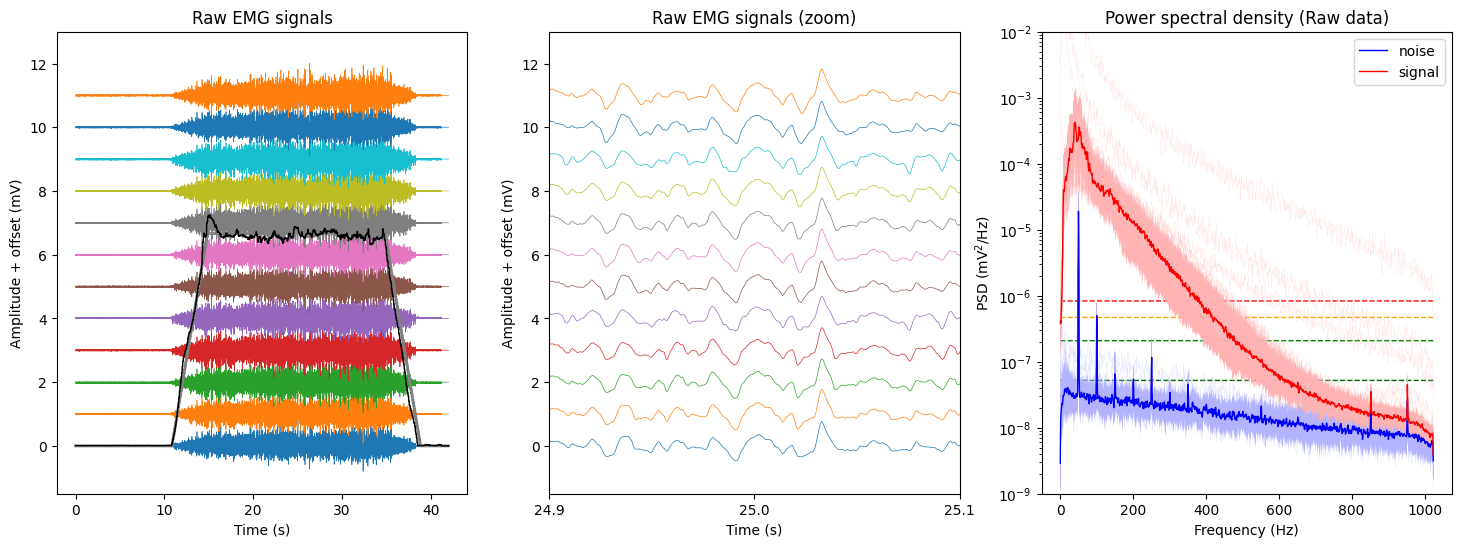

In [42]:
# Extract start and end of muscle activity from events.tsv
start_idx, end_idx = get_events_indices(emg_recording.events)

# Split up the signal into signal and noise 
sig = emg_data[:, start_idx:end_idx]
noise = emg_data[:,:start_idx]

# Analyse the data
results = analyse_signal(sig, noise)

# Plot data ans PSD
plot_data(emg_data, performed_path, requested_path, results, dtype="Raw")

#### Applying digital filters

Now, we will try to reject the three most dominat peaks of power line interference (i.e., the 50 and 100 and 250 Hz peaks) using a notch filter and restrict the signal of interest to the 20-500 Hz band using a bandpass filter (both implemented by means of a butterworth filter).  

This reduces the RMS<sub>noise</sub> roughly by a factor of two and the SNR are increases to 33.33 dB. We further observe that the noise floor in the 20-500 Hz band is nearly the same as before. Classic filtering does not allow us to reject this residual noise without simulataneously rejeting parts of the signal (as we e.g., do through the notch filter). It might be possible to slightly improve the signal quality through a more sophisticated filter design (see next part). However, unless we have an accurate noise model, we need to accept the residual noise to analyse the data (also highlighting the importance of high-quality raw data aquisition).


SNR: 33.33 dB.
RMS-Noise: 0.00344 mV
Median Noise Floor: 2.020e-08 mV^2/Hz
Power Line Interference: 0.88 dB


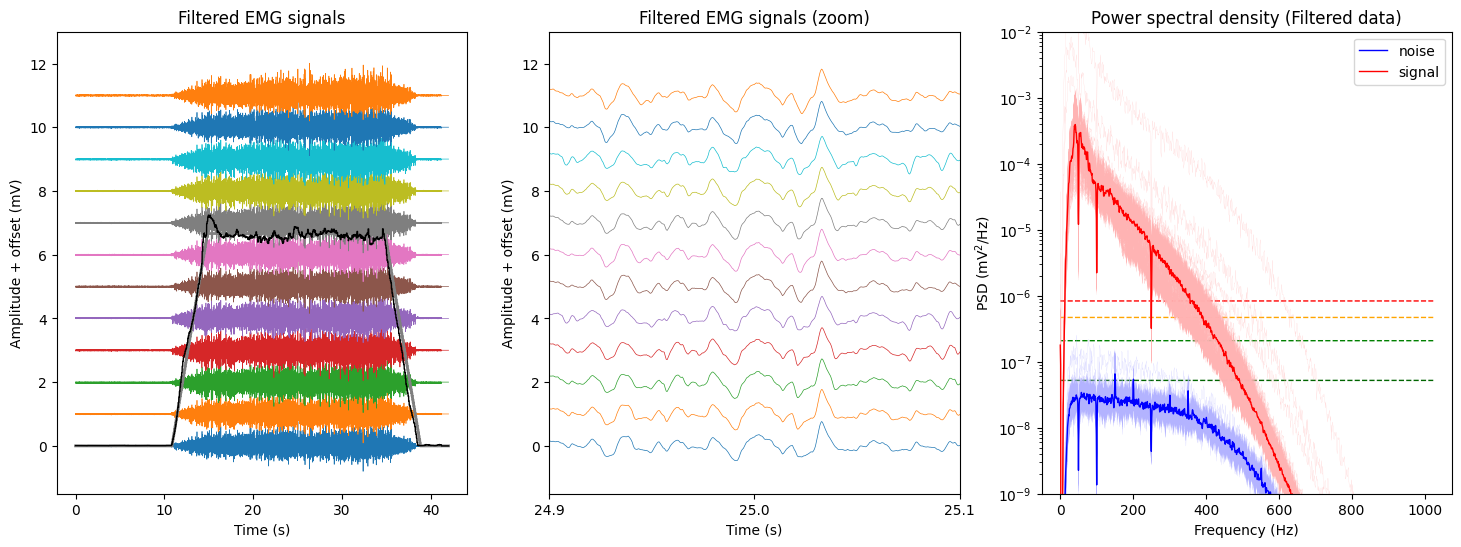

In [43]:
# Apply a notch filter
filtered_emg = emg_data.copy()
filtered_emg = notch_signals(
    data=filtered_emg, 
    fsamp=fsamp, 
    freqs=[50, 100, 250], 
    method="butter", 
    order=2
)
# Apply a bandpass filter
filtered_emg = bandpass_signals(
    data=filtered_emg, 
    fsamp=fsamp, 
    high_pass=20, 
    low_pass=500,
    method="butter",
    order=2
)

# Split up the signal into signal and noise 
sig = filtered_emg[:, start_idx:end_idx]
noise = filtered_emg[:,:start_idx]

# Analyse the data
results = analyse_signal(sig, noise)

# Plot data ans PSD
plot_data(emg_data, performed_path, requested_path, results, dtype="Filtered")


## Filter design

We have now seen that digital filtering (to some degree) helps us clean EMG and thus improves the SNR. There are multiple approaches to filtering data, and whether a specific filtering choice is good or bad depends on the raw data and your application. In motor unit identification, an important assumption is that the measured signal is a linear superposition of contributions from individual motor units. Hence, all filtering approaches implemented in the ``MUniverse`` framework are linear filters. The available options are outlined below. 

#### Notch filters

Here we provide three different filter types (infinite impulse response [``butterwoth``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) and [``iirnotch``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirnotch.html) filters  or ``fft-based``) for removing power line noise (or rejecting any other noise source affecting a narrow frequecny band). Their behavior is showcased in the following.

- Butterworth filters are solid general-purpose filters, due to their smooth transitions, particularly for removing broader frequency bands. However, it can also be used as a stop band filter. If you want a very sharp filter, you need to increase the filter order, which can cause numerical instabilities (here, when setting the order to a value higher than 4). So when selecting that option, you need to balance between sharpness and stability. 
- The IIR notch filter is also an infinite impulse response filter. However, it is specifically designed to reject narrow frequency bands and thus allows relativly low filter orders. 
- FFT-based filtering is particularly well suited when extremely precise frequency control is desired (you can design arbitrary filters by specifically selecting gains for each frequency bin). Thereby, one needs to be aware that harsh transitions can cause ringing, which is visible in the spectrum as an artificial increase in the PSD of neighboring frequencies. Moreover, it is only feasible for offline signal analysis. 

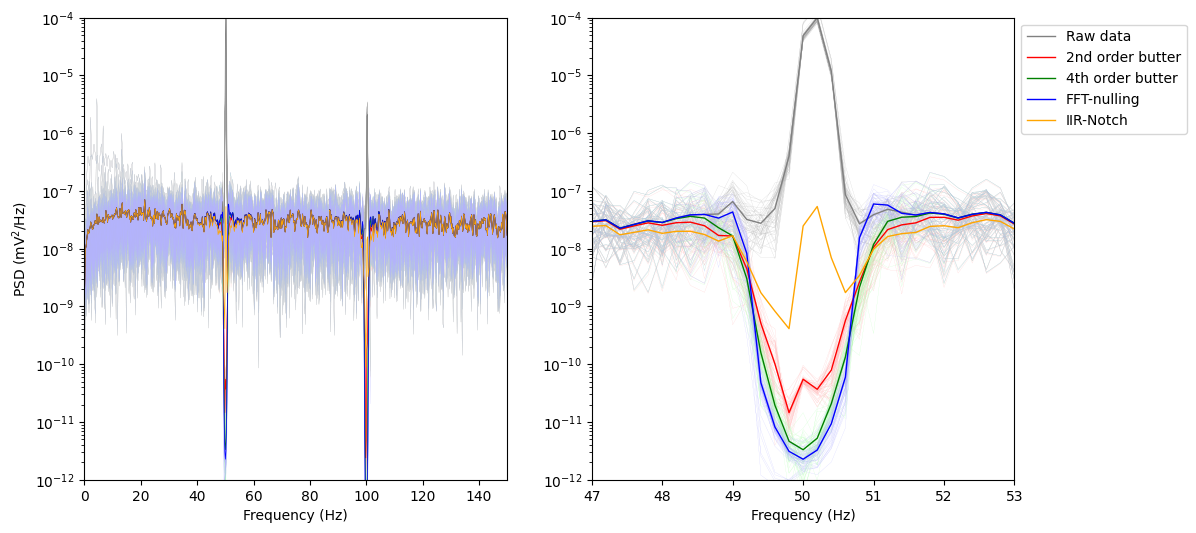

In [44]:
# Get the noise data
noise = emg_data[:,:start_idx]

# Try different filters
noise_notch_fft = notch_signals(noise, fsamp=fsamp, freqs=[50, 100], method='fft_nulling', dfreq=1.0)
noise_notch_butter2 = notch_signals(noise, fsamp=fsamp, freqs=[50, 100], method='butter', order=2)
noise_notch_butter4 = notch_signals(noise, fsamp=fsamp, freqs=[50, 100], method='butter', order=4)
noise_notch_iirnotch = notch_signals(noise, fsamp=fsamp, freqs=[50, 100], method='iirnotch', dfreq=1)

# Estimate the PSD
P_raw, f_raw = calc_PSD(noise, nperseg=5*fsamp, noverlap=fsamp)
P_fft, f_fft = calc_PSD(noise_notch_fft, nperseg=5*fsamp, noverlap=fsamp)
P_b2, f_b2 = calc_PSD(noise_notch_butter2, nperseg=5*fsamp, noverlap=fsamp)
P_b4, f_b4 = calc_PSD(noise_notch_butter4, nperseg=5*fsamp, noverlap=fsamp)
P_iir, f_iir = calc_PSD(noise_notch_iirnotch, nperseg=5*fsamp, noverlap=fsamp)

# Plot spectra
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].semilogy(f_raw,P_raw[::5,:].T, lw=0.1, color=[0.7, 0.7, 0.7])
ax[0].semilogy(f_b2,P_b2[::5,:].T, lw=0.1, color=[1, 0.7, 0.7])
ax[0].semilogy(f_b4,P_b4[::5,:].T, lw=0.1, color=[0.7, 1, 0.7])
ax[0].semilogy(f_fft,P_fft[::5,:].T, lw=0.1, color=[0.7, 0.7, 1])
ax[0].semilogy(f_raw,np.mean(P_raw, axis=0), lw=0.5, color="gray", label="Raw data")
ax[0].semilogy(f_b2,np.mean(P_b2, axis=0), lw=0.5, color="red", label="2nd order butter")
ax[0].semilogy(f_b4,np.mean(P_b4, axis=0), lw=0.5, color="green", label="4th order butter")
ax[0].semilogy(f_fft,np.mean(P_fft, axis=0), lw=0.5, color="blue", label="FFT-Nulling")
ax[0].semilogy(f_iir,np.mean(P_iir, axis=0), lw=0.5, color="orange", label="IIR-Notch")
ax[0].set_ylim(1e-12,1e-4)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("PSD (mV$^2$/Hz)")
ax[0].set_xlim(0, 150)

ax[1].semilogy(f_raw,P_raw[::5,:].T, lw=0.1, color=[0.7, 0.7, 0.7])
ax[1].semilogy(f_b2,P_b2[::5,:].T, lw=0.1, color=[1, 0.7, 0.7])
ax[1].semilogy(f_b4,P_b4[::5,:].T, lw=0.1, color=[0.7, 1, 0.7])
ax[1].semilogy(f_fft,P_fft[::5,:].T, lw=0.1, color=[0.7, 0.7, 1])
ax[1].semilogy(f_raw,np.mean(P_raw, axis=0), lw=1, color="gray", label="Raw data")
ax[1].semilogy(f_b2,np.mean(P_b2, axis=0), lw=1, color="red", label="2nd order butter")
ax[1].semilogy(f_b4,np.mean(P_b4, axis=0), lw=1, color="green", label="4th order butter")
ax[1].semilogy(f_fft,np.mean(P_fft, axis=0), lw=1, color="blue", label="FFT-nulling")
ax[1].semilogy(f_iir,np.mean(P_iir, axis=0), lw=1, color="orange", label="IIR-Notch")
ax[1].set_ylim(1e-12,1e-4)
ax[1].set_xlim(47, 53)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()




#### Bandpass filters

By using lowpass, highpass, or bandpass filters, one tries to eliminate noise in frequency bands not overlapping with the signal. Surface EMG signals are expected to have a bandwidth ranging from 10 to several hundred Hz. In ``MUniverse``, we have currently implemented two types of bandpass filters (the same options are available as high and low pass filters):

- [``Firwin2``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.firwin2.html) corresponds to a finite impulse response (FIR) filter. This type of filter allows for relatively sharp cut-offs and is numerically stable. The sharpness can be controlled by the length of the filter window ("numtabs"), which also increases the computational cost.
- The [``Butterworth``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) filter is an infinite impulse response (IIR) filter. The cutoffs can be precisely controlled and are rather smooth. Furthermore, a Butterworth filter is computationally efficient. As discussed before, one needs to balance sharpness and numerical stability.


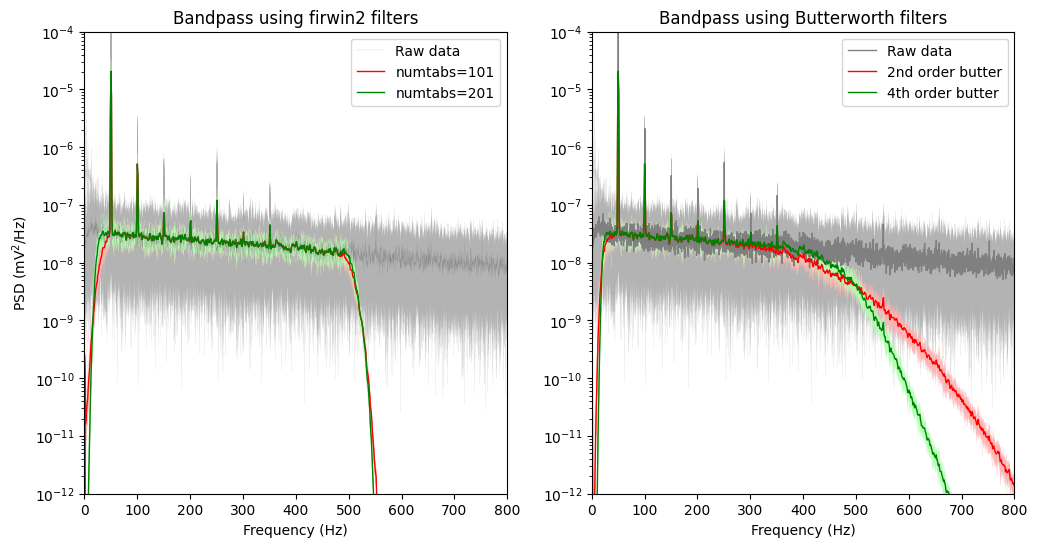

In [45]:
# Get the noise data
noise = emg_data[:,:start_idx]

# Try different filters
noise_firwin201 = bandpass_signals(noise, fsamp=fsamp, method='firwin2', numtabs=201)
noise_firwin101 = bandpass_signals(noise, fsamp=fsamp, method='firwin2', numtabs=101)
noise_band_butter2 = bandpass_signals(noise, fsamp=fsamp, method='butter', order=2)
noise_band_butter4 = bandpass_signals(noise, fsamp=fsamp, method='butter', order=4)

P_fw201, f_fw201 = calc_PSD(noise_firwin201)
P_fw101, f_fw101 = calc_PSD(noise_firwin101)
P_b2, f_b2 = calc_PSD(noise_band_butter2)
P_b4, f_b4 = calc_PSD(noise_band_butter4)

# Plot spectra
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].semilogy(f_raw,P_raw[::5,:].T, lw=0.1, color=[0.7, 0.7, 0.7])
ax[0].semilogy(f_fw101,P_fw101[::5,:].T, lw=0.1, color=[1, 0.7, 0.7])
ax[0].semilogy(f_fw201,P_fw201[::5,:].T, lw=0.1, color=[0.7, 1, 0.7])
ax[0].semilogy(f_raw,np.mean(P_raw, axis=0), lw=0.1, color="gray", label="Raw data")
ax[0].semilogy(f_fw101,np.mean(P_fw101, axis=0), lw=1, color="red", label="numtabs=101")
ax[0].semilogy(f_fw201,np.mean(P_fw201, axis=0), lw=1, color="green", label="numtabs=201")
ax[0].set_ylim(1e-12,1e-4)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("PSD (mV$^2$/Hz)")
ax[0].legend(loc='upper right')
ax[0].set_title("Bandpass using firwin2 filters")
ax[0].set_xlim(0, 800)

ax[1].semilogy(f_raw,P_raw[::5,:].T, lw=0.1, color=[0.7, 0.7, 0.7])
ax[1].semilogy(f_b2,P_b2[::5,:].T, lw=0.1, color=[1, 0.7, 0.7])
ax[1].semilogy(f_b4,P_b4[::5,:].T, lw=0.1, color=[0.7, 1, 0.7])
ax[1].semilogy(f_raw,np.mean(P_raw, axis=0), lw=1, color="gray", label="Raw data")
ax[1].semilogy(f_b2,np.mean(P_b2, axis=0), lw=1, color="red", label="2nd order butter")
ax[1].semilogy(f_b4,np.mean(P_b4, axis=0), lw=1, color="green", label="4th order butter")
ax[1].set_ylim(1e-12,1e-4)
ax[1].set_xlim(0, 800)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].legend(loc='upper right')
ax[1].set_title("Bandpass using Butterworth filters")
plt.show()


## References

[1] Muceli, S., & Merletti, R. (2024). Tutorial. Frequency analysis of the surface EMG signal: Best practices. Journal of Electromyography and Kinesiology, 79, 102937.

[2] Farago, E., MacIsaac, D., Suk, M., & Chan, A. D. (2022). A review of techniques for surface electromyography signal quality analysis. IEEE Reviews in Biomedical Engineering, 16, 472-486.

[3] De Luca, C. J., Gilmore, L. D., Kuznetsov, M., & Roy, S. H. (2010). Filtering the surface EMG signal: Movement artifact and baseline noise contamination. Journal of biomechanics, 43(8), 1573-1579.